<a href="https://www.kaggle.com/code/aamir28/nyc-exam-results-report?scriptVersionId=338702550" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:#FFFFFF; padding:42px 40px; border-radius:4px; border:1px solid #D6D9DC; border-top:6px solid #003057; font-family:Georgia,'Times New Roman',serif;">

  <div style="display:flex; justify-content:space-between; align-items:flex-start; margin-bottom:18px;">
    <div>
      <span style="font-family:Arial,sans-serif; font-size:11px; font-weight:700; color:#003057; letter-spacing:1.5px; text-transform:uppercase;">NYC Department of Education</span><br/>
      <span style="font-family:Arial,sans-serif; font-size:11px; color:#6E6E73;">Office of Assessment &amp; Accountability — Public Data Release</span>
    </div>
    <div style="text-align:right; font-family:Arial,sans-serif; font-size:11px; color:#6E6E73;">
      DATA FILE: 2014–15 to 2018–19<br/>Released 2026-07-24
    </div>
  </div>

  <div style="height:2px; background:#003057; margin-bottom:20px;"></div>

  <h1 style="margin:0 0 8px 0; font-size:32px; color:#1A1A1A; font-weight:700;">
    Regents Exam Results Report
  </h1>
  <p style="margin:0 0 26px 0; font-size:15px; color:#4A4A4A; font-family:Arial,sans-serif;">
    Five school years of Regents scores across 1,081 NYC schools, 18 exam subjects, and all five boroughs
  </p>

  <table style="width:100%; border-collapse:collapse; font-family:Arial,sans-serif; font-size:13px;">
    <tr style="background:#F2F4F6;">
      <td style="padding:10px 14px; border:1px solid #D6D9DC; font-weight:700; color:#003057;">Records</td>
      <td style="padding:10px 14px; border:1px solid #D6D9DC;">33,031</td>
      <td style="padding:10px 14px; border:1px solid #D6D9DC; font-weight:700; color:#003057;">Schools</td>
      <td style="padding:10px 14px; border:1px solid #D6D9DC;">1,081</td>
    </tr>
    <tr>
      <td style="padding:10px 14px; border:1px solid #D6D9DC; font-weight:700; color:#003057;">Exam subjects</td>
      <td style="padding:10px 14px; border:1px solid #D6D9DC;">18</td>
      <td style="padding:10px 14px; border:1px solid #D6D9DC; font-weight:700; color:#003057;">School years</td>
      <td style="padding:10px 14px; border:1px solid #D6D9DC;">2015 – 2019</td>
    </tr>
  </table>

  <p style="margin:20px 0 0 0; font-size:12px; color:#6E6E73; font-family:Arial,sans-serif; line-height:1.7;">
    Prepared by: <b style="color:#1A1A1A;">Muhammad Aamir</b> &nbsp;|&nbsp;
    Note: rows for cohorts of 5 or fewer students are suppressed by NYC DOE to protect student privacy —
    see Section 3 for how we handle this.
  </p>

</div>



<div style="background:#F2F4F6; border-left:4px solid #003057; padding:20px 26px; font-family:Arial,Helvetica,sans-serif; color:#1A1A1A;">
<h3 style="margin-top:0; font-weight:700; color:#003057; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">Table of Contents</h3>
<ol style="line-height:2; font-size:14.5px; color:#333;">
<li><a href="#setup" style="color:#003057; text-decoration:none;">Setup &amp; Report Styling</a></li>
<li><a href="#firstlook" style="color:#003057; text-decoration:none;">First Look at the File</a></li>
<li><a href="#quality" style="color:#003057; text-decoration:none;">Data Quality &amp; Cleaning</a></li>
<li><a href="#examland" style="color:#003057; text-decoration:none;">The Exam Landscape</a></li>
<li><a href="#trends" style="color:#003057; text-decoration:none;">Trends Over Time (2015–2019)</a></li>
<li><a href="#schooltype" style="color:#003057; text-decoration:none;">School Type &amp; Level</a></li>
<li><a href="#borough" style="color:#003057; text-decoration:none;">Borough Breakdown</a></li>
<li><a href="#schools" style="color:#003057; text-decoration:none;">Top &amp; Bottom Performing Schools</a></li>
<li><a href="#cohort" style="color:#003057; text-decoration:none;">Does Cohort Size Matter?</a></li>
<li><a href="#dashboard" style="color:#003057; text-decoration:none;">Summary Dashboard</a></li>
<li><a href="#model" style="color:#003057; text-decoration:none;">Predicting the Mean Score</a></li>
<li><a href="#conclusion" style="color:#003057; text-decoration:none;">Closing Notes</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:Arial,Helvetica,sans-serif; color:#003057; border-bottom:3px solid #003057; padding-bottom:8px;">⚙️ 1. Setup &amp; Report Styling</h2>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "NYC DOE Report Card" civic palette ----
BG        = '#FFFFFF'
PANEL     = '#F2F4F6'
INK       = '#1A1A1A'
INK_SOFT  = '#6E6E73'
NAVY      = '#003057'
SUBWAY_A  = '#0039A6'   # A/C/E line blue
SUBWAY_B  = '#FF6319'   # B/D/F/M line orange
SUBWAY_G  = '#6CBE45'   # G line green
SUBWAY_4  = '#EE352E'   # 4/5/6 line red
SUBWAY_7  = '#B933AD'   # 7 line purple
GRID      = '#D6D9DC'

BOROUGH_NAMES = {'M':'Manhattan','X':'Bronx','K':'Brooklyn','Q':'Queens','R':'Staten Island'}
BOROUGH_COLORS = {'Manhattan': SUBWAY_A, 'Bronx': SUBWAY_4, 'Brooklyn': SUBWAY_B, 'Queens': SUBWAY_7, 'Staten Island': SUBWAY_G}
PALETTE_CAT = [NAVY, SUBWAY_B, SUBWAY_4, SUBWAY_7, SUBWAY_G, SUBWAY_A]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': BG,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12, fontsize=13)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Report styling loaded.")


Report styling loaded.


<h2 id="firstlook" style="font-family:Arial,Helvetica,sans-serif; color:#003057; border-bottom:3px solid #003057; padding-bottom:8px;">📄 2. First Look at the File</h2>

In [2]:

df = pd.read_csv('/kaggle/input/datasets/razanihababdellatif/nyc-regents-exam-dataset/2014-15_to_2017-19_NYC_Regents_Exam_Results_-_Public_20260724.csv', low_memory=False)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
df.head(6)


Shape: 33,031 rows x 18 columns



,Unnamed Column,School DBN,School Name,School Type,School Level,Regents Exam,Year,Category,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,08X5072015All StudentsGeometry,08X507,Stevenson Yabc,YABC,High school,Geometry,2015,All Students,1,s,s,s,s,s,s,s,s,s
1,01M1842018All StudentsLiving Environment,01M184,P.S. 184m Shuang Wen,General Academic,K-8,Living Environment,2018,All Students,32,90.2,0,0.0,32,100.0,31,96.9,na,na
2,01M4582019All StudentsSpanish,01M458,Forsyth Satellite Academy,Transfer School,High school,Spanish,2019,All Students,1,s,s,s,s,s,s,s,s,s
3,01M5092017All StudentsSpanish,01M509,Marta Valle High School,General Academic,High school,Spanish,2017,All Students,16,82.7,0,0.0,16,100.0,10,62.5,na,na
4,02M2982015All StudentsGeometry,02M298,Pace High School,General Academic,High school,Geometry,2015,All Students,163,62.9,81,49.7,82,50.3,13,8.0,13,8.0
5,02M3162015All StudentsItalian,02M316,Urban Assembly School of Business for Young Wo...,General Academic,High school,Italian,2015,All Students,1,s,s,s,s,s,s,s,s,s


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33031 entries, 0 to 33030
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed Column               33031 non-null  object
 1   School DBN                   33031 non-null  object
 2   School Name                  33031 non-null  object
 3   School Type                  33031 non-null  object
 4   School Level                 33031 non-null  object
 5   Regents Exam                 33031 non-null  object
 6   Year                         33031 non-null  int64 
 7   Category                     33031 non-null  object
 8   Total Tested                 33031 non-null  object
 9   Mean Score                   33031 non-null  object
 10  Number Scoring Below 65      33031 non-null  object
 11  Percent Scoring Below 65     33031 non-null  object
 12  Number Scoring 65 or Above   33031 non-null  object
 13  Percent Scoring 65 or Above  33

<h2 id="quality" style="font-family:Arial,Helvetica,sans-serif; color:#003057; border-bottom:3px solid #003057; padding-bottom:8px;">🧹 3. Data Quality &amp; Cleaning</h2>
<p style="color:#4A4A4A; font-family:Arial,Helvetica,sans-serif;">This is real government open data, and it comes with the quirks real government data always has: comma-formatted numbers stored as text, and privacy-driven suppression codes instead of raw counts.</p>

In [4]:

# 1) Total Tested is stored as text with thousands-separators for large cohorts
print("Sample of 'Total Tested' raw values:", df['Total Tested'].astype(str).sample(5, random_state=1).tolist())
df['Total Tested'] = df['Total Tested'].astype(str).str.replace(',', '').astype(int)

# 2) 's' marks a suppressed cohort (NYC DOE suppresses any group of 5 or fewer students, to protect privacy)
numeric_cols = ['Mean Score', 'Number Scoring Below 65', 'Percent Scoring Below 65',
                'Number Scoring 65 or Above', 'Percent Scoring 65 or Above',
                'Number Scoring 80 or Above', 'Percent Scoring 80 or Above',
                'Number Scoring CR', 'Percent Scoring CR']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

suppressed = df['Mean Score'].isna()
print(f"\nSuppressed ('s') rows: {suppressed.sum():,} of {len(df):,} ({suppressed.mean()*100:.1f}%)")
print("Cohort size for suppressed rows:")
print(df[suppressed]['Total Tested'].describe())


Sample of 'Total Tested' raw values: ['92', '99', '85', '41', '125']

Suppressed ('s') rows: 3,531 of 33,031 (10.7%)
Cohort size for suppressed rows:
count    3531.000000
mean        2.129142
std         1.356248
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: Total Tested, dtype: float64


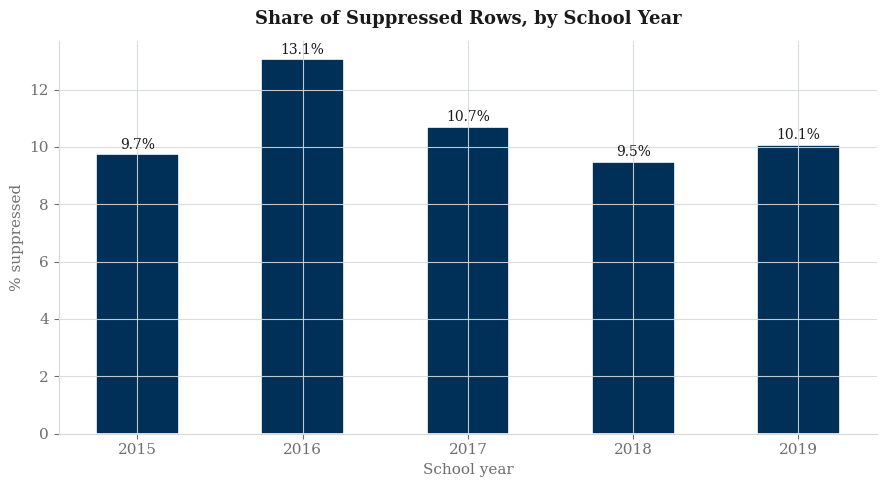


Working dataset after dropping suppressed rows: 29,500 rows (89.3% of the original).


In [5]:

supp_by_year = df.groupby('Year').apply(lambda g: g['Mean Score'].isna().mean()*100)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(supp_by_year.index.astype(str), supp_by_year.values, color=NAVY, edgecolor=BG, linewidth=1.2, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2, f"{b.get_height():.1f}%", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Share of Suppressed Rows, by School Year', 'School year', '% suppressed')
plt.tight_layout()
plt.show()

df_clean = df.dropna(subset=['Mean Score']).copy()
print(f"\nWorking dataset after dropping suppressed rows: {len(df_clean):,} rows ({len(df_clean)/len(df)*100:.1f}% of the original).")



<div style="background:#F2F4F6; border-left:3px solid #003057; padding:14px 20px; font-family:Arial,Helvetica,sans-serif; color:#333; font-size:14px;">
<b>This suppression is expected, not a defect.</b> Every suppressed row's cohort is 5 students or fewer — exactly
NYC DOE's documented privacy threshold — so dropping these rows for our aggregate analysis is the right move rather
than trying to impute scores DOE deliberately withheld. We'll work with the remaining 89% of rows for every
analysis below.
</div>


<h2 id="examland" style="font-family:Arial,Helvetica,sans-serif; color:#003057; border-bottom:3px solid #003057; padding-bottom:8px;">📚 4. The Exam Landscape</h2>

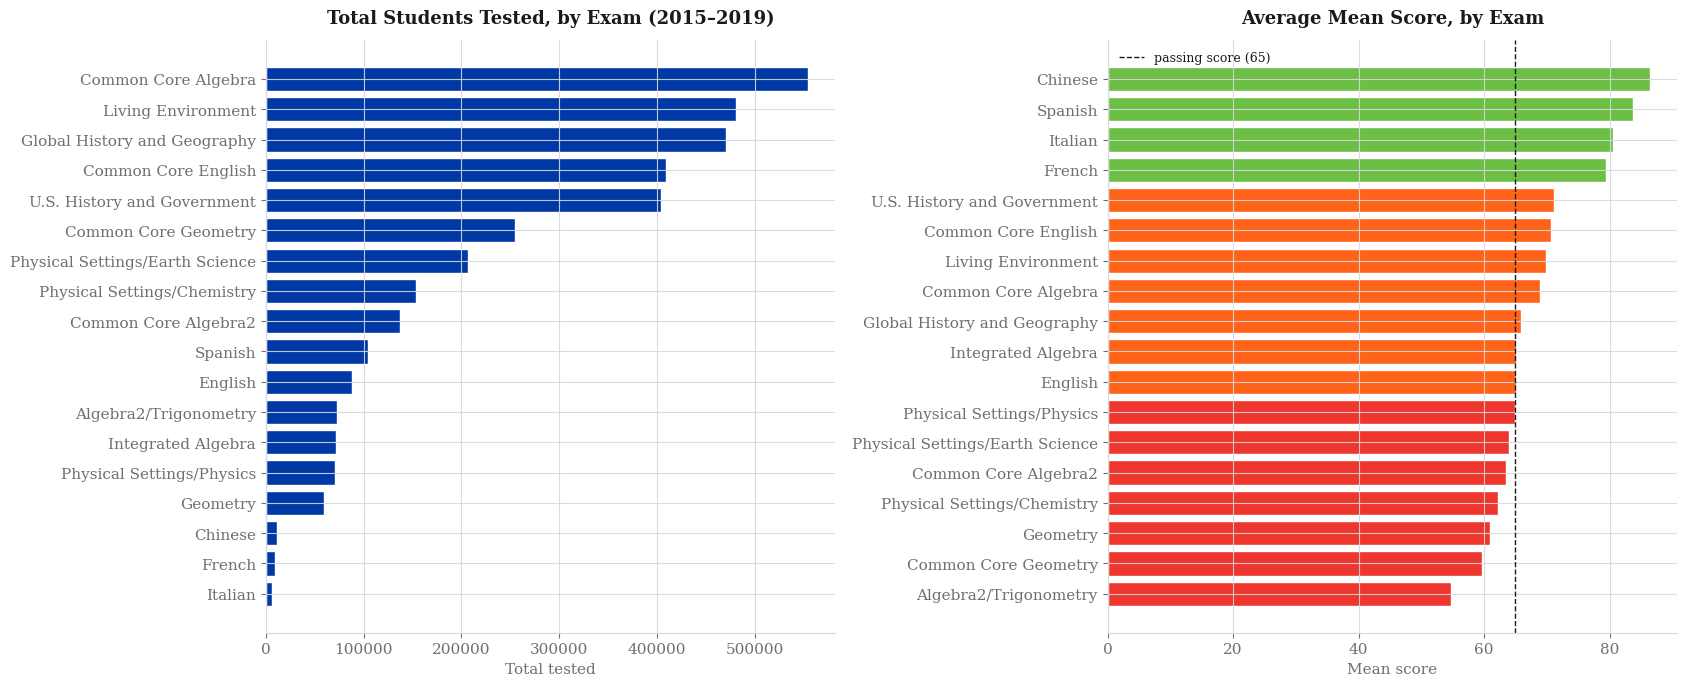

Common Core Algebra, Living Environment and Global History are the three most-tested exams —
the core subjects required for graduation across most NYC high schools.


In [6]:

exam_popularity = df_clean.groupby('Regents Exam')['Total Tested'].sum().sort_values(ascending=False)
exam_score = df_clean.groupby('Regents Exam')['Mean Score'].mean().reindex(exam_popularity.index)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

ax = axes[0]
bars = ax.barh(exam_popularity.index[::-1], exam_popularity.values[::-1], color=SUBWAY_A, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Total Students Tested, by Exam (2015–2019)', 'Total tested', '')

ax = axes[1]
exam_score_sorted = exam_score.sort_values()
colors = [SUBWAY_4 if v<65 else (SUBWAY_B if v<75 else SUBWAY_G) for v in exam_score_sorted.values]
bars = ax.barh(exam_score_sorted.index, exam_score_sorted.values, color=colors, edgecolor=BG, linewidth=1.0)
ax.axvline(65, color=INK, linestyle='--', linewidth=1, label='passing score (65)')
style_ax(ax, 'Average Mean Score, by Exam', 'Mean score', '')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

print("Common Core Algebra, Living Environment and Global History are the three most-tested exams —")
print("the core subjects required for graduation across most NYC high schools.")


<h2 id="trends" style="font-family:Arial,Helvetica,sans-serif; color:#003057; border-bottom:3px solid #003057; padding-bottom:8px;">📈 5. Trends Over Time (2015–2019)</h2>

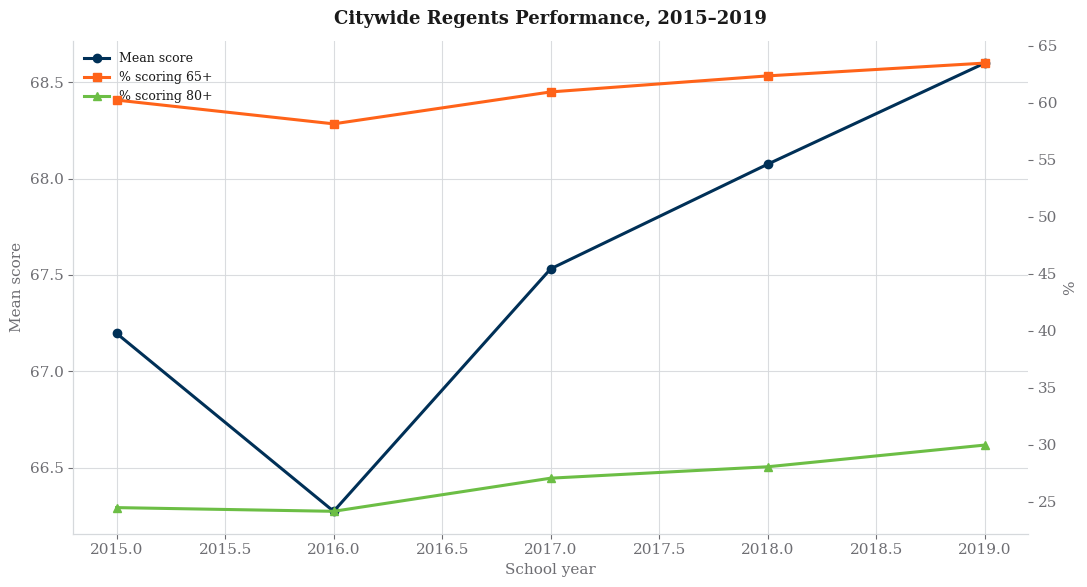

Citywide mean score rose from 67.2 (2015) to 68.6 (2019),
and the share scoring 65+ rose from 60.2% to 63.5% over the same span.


In [7]:

year_trend = df_clean.groupby('Year').agg(
    mean_score=('Mean Score','mean'),
    pass_rate=('Percent Scoring 65 or Above','mean'),
    mastery_rate=('Percent Scoring 80 or Above','mean')
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(year_trend.index, year_trend['mean_score'], color=NAVY, linewidth=2.2, marker='o', markersize=6, label='Mean score')
ax2 = ax.twinx()
ax2.plot(year_trend.index, year_trend['pass_rate'], color=SUBWAY_B, linewidth=2.2, marker='s', markersize=6, label='% scoring 65+')
ax2.plot(year_trend.index, year_trend['mastery_rate'], color=SUBWAY_G, linewidth=2.2, marker='^', markersize=6, label='% scoring 80+')
ax2.grid(False)
style_ax(ax, 'Citywide Regents Performance, 2015–2019', 'School year', 'Mean score')
ax2.set_ylabel('%', color=INK_SOFT)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print(f"Citywide mean score rose from {year_trend['mean_score'].iloc[0]:.1f} (2015) to {year_trend['mean_score'].iloc[-1]:.1f} (2019),")
print(f"and the share scoring 65+ rose from {year_trend['pass_rate'].iloc[0]:.1f}% to {year_trend['pass_rate'].iloc[-1]:.1f}% over the same span.")


<h2 id="schooltype" style="font-family:Arial,Helvetica,sans-serif; color:#003057; border-bottom:3px solid #003057; padding-bottom:8px;">🏫 6. School Type &amp; Level</h2>

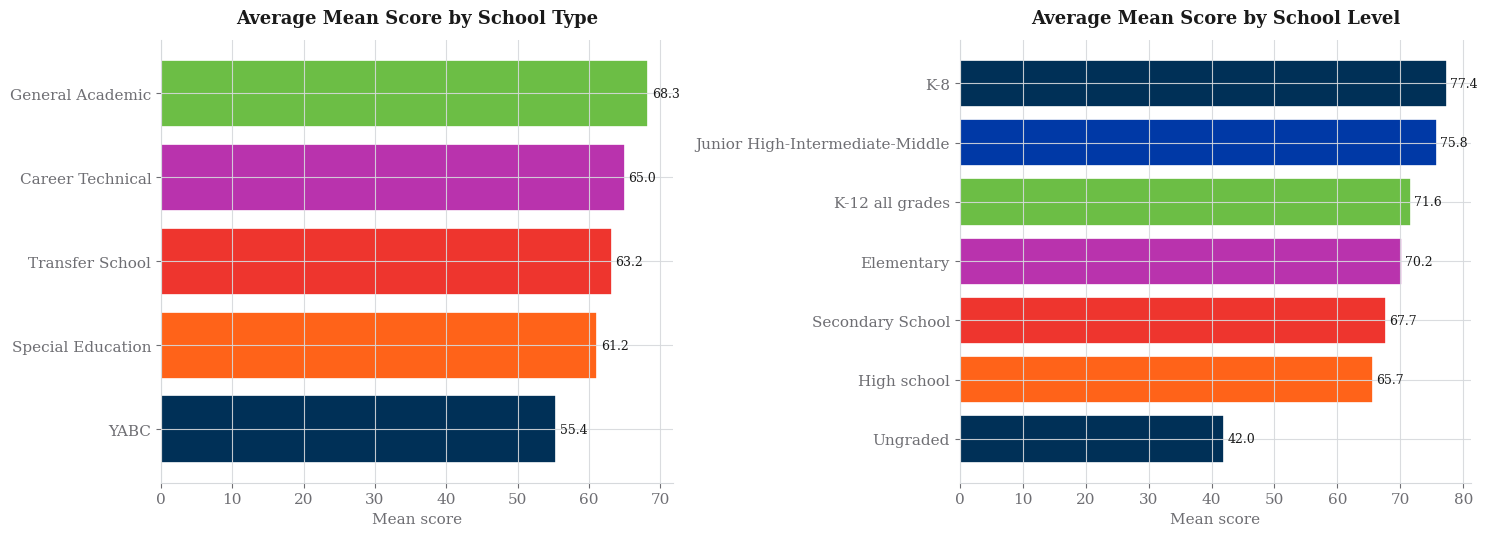

YABC (Young Adult Borough Centers, serving over-age/under-credit students) and Transfer Schools score
lowest — consistent with their mission of serving students who've struggled in a traditional track,
while General Academic schools score highest.


In [8]:

type_score = df_clean.groupby('School Type')['Mean Score'].mean().sort_values()
level_score = df_clean.groupby('School Level')['Mean Score'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
bars = ax.barh(type_score.index, type_score.values, color=PALETTE_CAT[:len(type_score)], edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+0.5, b.get_y()+b.get_height()/2, f"{b.get_width():.1f}", va='center', fontsize=9, color=INK)
style_ax(ax, 'Average Mean Score by School Type', 'Mean score', '')

ax = axes[1]
bars = ax.barh(level_score.index, level_score.values, color=PALETTE_CAT[:len(level_score)], edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+0.5, b.get_y()+b.get_height()/2, f"{b.get_width():.1f}", va='center', fontsize=9, color=INK)
style_ax(ax, 'Average Mean Score by School Level', 'Mean score', '')

plt.tight_layout()
plt.show()

print("YABC (Young Adult Borough Centers, serving over-age/under-credit students) and Transfer Schools score")
print("lowest — consistent with their mission of serving students who've struggled in a traditional track,")
print("while General Academic schools score highest.")


<h2 id="borough" style="font-family:Arial,Helvetica,sans-serif; color:#003057; border-bottom:3px solid #003057; padding-bottom:8px;">🗺️ 7. Borough Breakdown</h2>

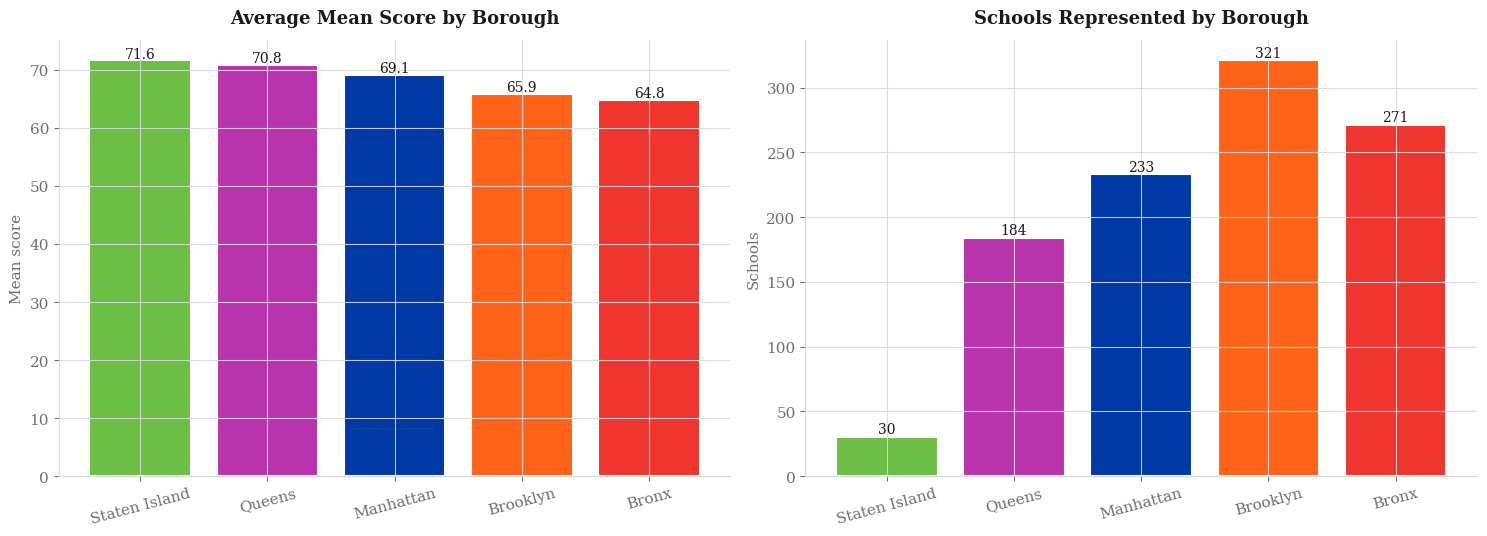

In [9]:

df_clean['Borough'] = df_clean['School DBN'].str[2].map(BOROUGH_NAMES)
boro_stats = df_clean.groupby('Borough').agg(mean_score=('Mean Score','mean'), n_schools=('School DBN','nunique')).sort_values('mean_score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
bars = ax.bar(boro_stats.index, boro_stats['mean_score'], color=[BOROUGH_COLORS[b] for b in boro_stats.index], edgecolor=BG, linewidth=1.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.1f}", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Average Mean Score by Borough', '', 'Mean score')
plt.setp(ax.get_xticklabels(), rotation=15)

ax = axes[1]
bars = ax.bar(boro_stats.index, boro_stats['n_schools'], color=[BOROUGH_COLORS[b] for b in boro_stats.index], edgecolor=BG, linewidth=1.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+3, int(b.get_height()), ha='center', fontsize=10, color=INK)
style_ax(ax, 'Schools Represented by Borough', '', 'Schools')
plt.setp(ax.get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()


<h2 id="schools" style="font-family:Arial,Helvetica,sans-serif; color:#003057; border-bottom:3px solid #003057; padding-bottom:8px;">🏆 8. Top &amp; Bottom Performing Schools</h2>
<p style="color:#4A4A4A; font-family:Arial,Helvetica,sans-serif;">Restricted to schools with at least 20 recorded exam-subject-years, so single-cohort flukes don't dominate the ranking.</p>

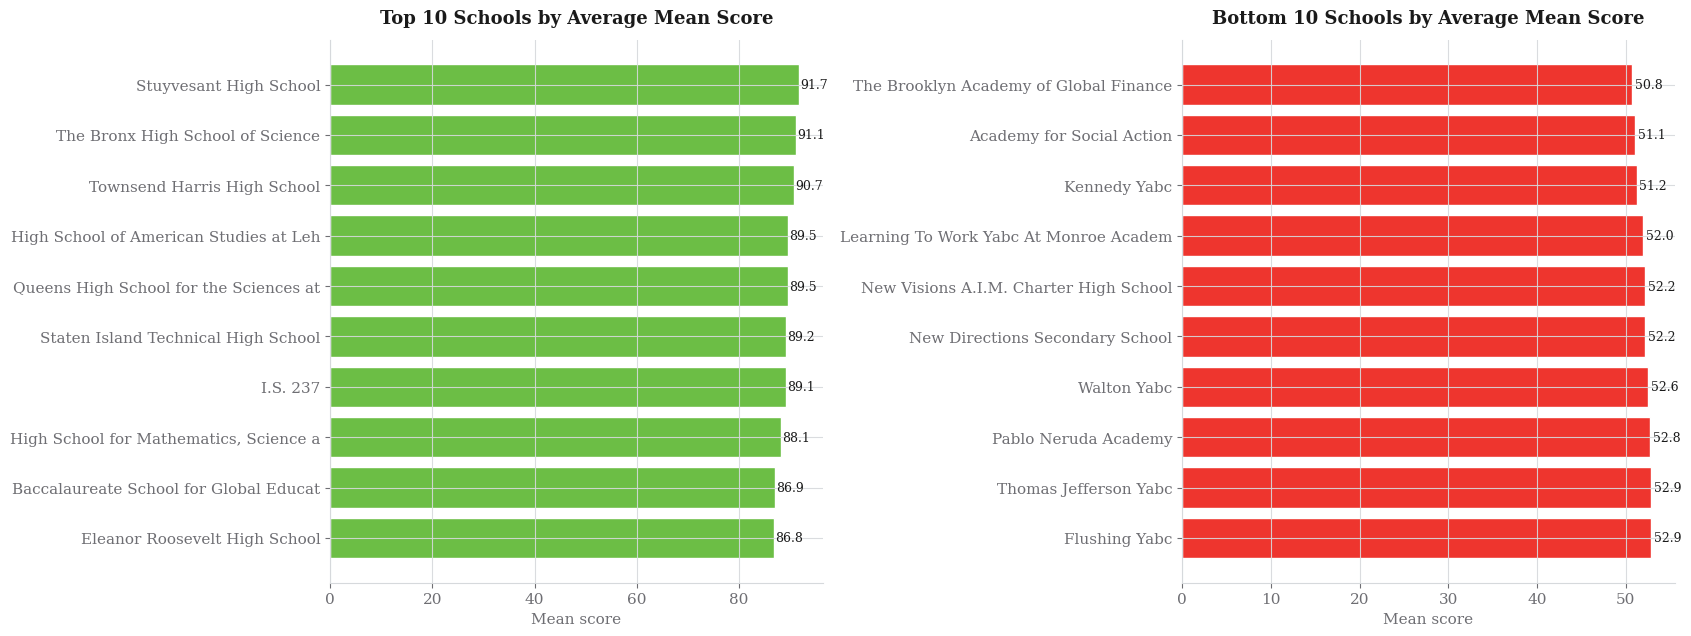

The top 10 is dominated by NYC's specialized/screened high schools (Stuyvesant, Bronx Science, Townsend
Harris) — a pattern that matches well-documented real-world outcomes for these exam-admission schools.


In [10]:

school_stats = df_clean.groupby('School Name').agg(avg_score=('Mean Score','mean'), n=('Mean Score','size'))
school_stats = school_stats[school_stats['n'] >= 20]
top10 = school_stats.sort_values('avg_score', ascending=False).head(10)
bottom10 = school_stats.sort_values('avg_score').head(10)

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

ax = axes[0]
bars = ax.barh([s[:38] for s in top10.index[::-1]], top10['avg_score'].values[::-1], color=SUBWAY_G, edgecolor=BG, linewidth=1.0)
for b in bars:
    ax.text(b.get_width()+0.3, b.get_y()+b.get_height()/2, f"{b.get_width():.1f}", va='center', fontsize=9, color=INK)
style_ax(ax, 'Top 10 Schools by Average Mean Score', 'Mean score', '')

ax = axes[1]
bars = ax.barh([s[:38] for s in bottom10.index[::-1]], bottom10['avg_score'].values[::-1], color=SUBWAY_4, edgecolor=BG, linewidth=1.0)
for b in bars:
    ax.text(b.get_width()+0.3, b.get_y()+b.get_height()/2, f"{b.get_width():.1f}", va='center', fontsize=9, color=INK)
style_ax(ax, 'Bottom 10 Schools by Average Mean Score', 'Mean score', '')

plt.tight_layout()
plt.show()

print("The top 10 is dominated by NYC's specialized/screened high schools (Stuyvesant, Bronx Science, Townsend")
print("Harris) — a pattern that matches well-documented real-world outcomes for these exam-admission schools.")


<h2 id="cohort" style="font-family:Arial,Helvetica,sans-serif; color:#003057; border-bottom:3px solid #003057; padding-bottom:8px;">📏 9. Does Cohort Size Matter?</h2>

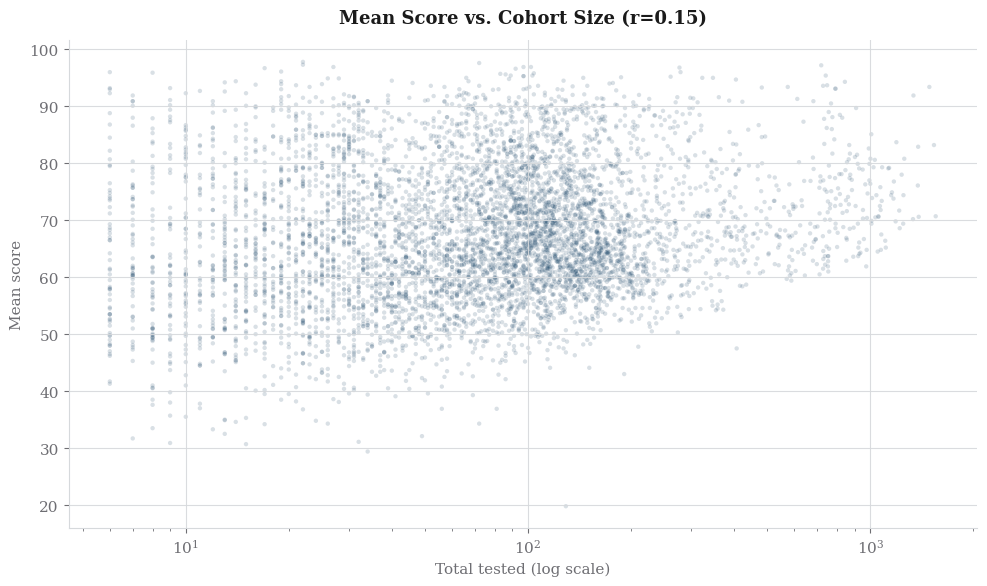

Only a weak positive relationship (r≈0.15) — larger exam cohorts trend slightly higher on average, likely
reflecting that bigger schools/exams draw from bigger, more resourced student populations, but cohort size
alone explains very little of the variation in mean score.


In [11]:

fig, ax = plt.subplots(figsize=(10, 6))
sample = df_clean.sample(min(6000, len(df_clean)), random_state=1)
ax.scatter(sample['Total Tested'], sample['Mean Score'], alpha=0.15, s=10, color=NAVY, edgecolor='none')
ax.set_xscale('log')
style_ax(ax, f"Mean Score vs. Cohort Size (r={df_clean['Total Tested'].corr(df_clean['Mean Score']):.2f})", 'Total tested (log scale)', 'Mean score')
plt.tight_layout()
plt.show()

print("Only a weak positive relationship (r≈0.15) — larger exam cohorts trend slightly higher on average, likely")
print("reflecting that bigger schools/exams draw from bigger, more resourced student populations, but cohort size")
print("alone explains very little of the variation in mean score.")


<h2 id="dashboard" style="font-family:Arial,Helvetica,sans-serif; color:#003057; border-bottom:3px solid #003057; padding-bottom:8px;">📊 10. Summary Dashboard</h2>

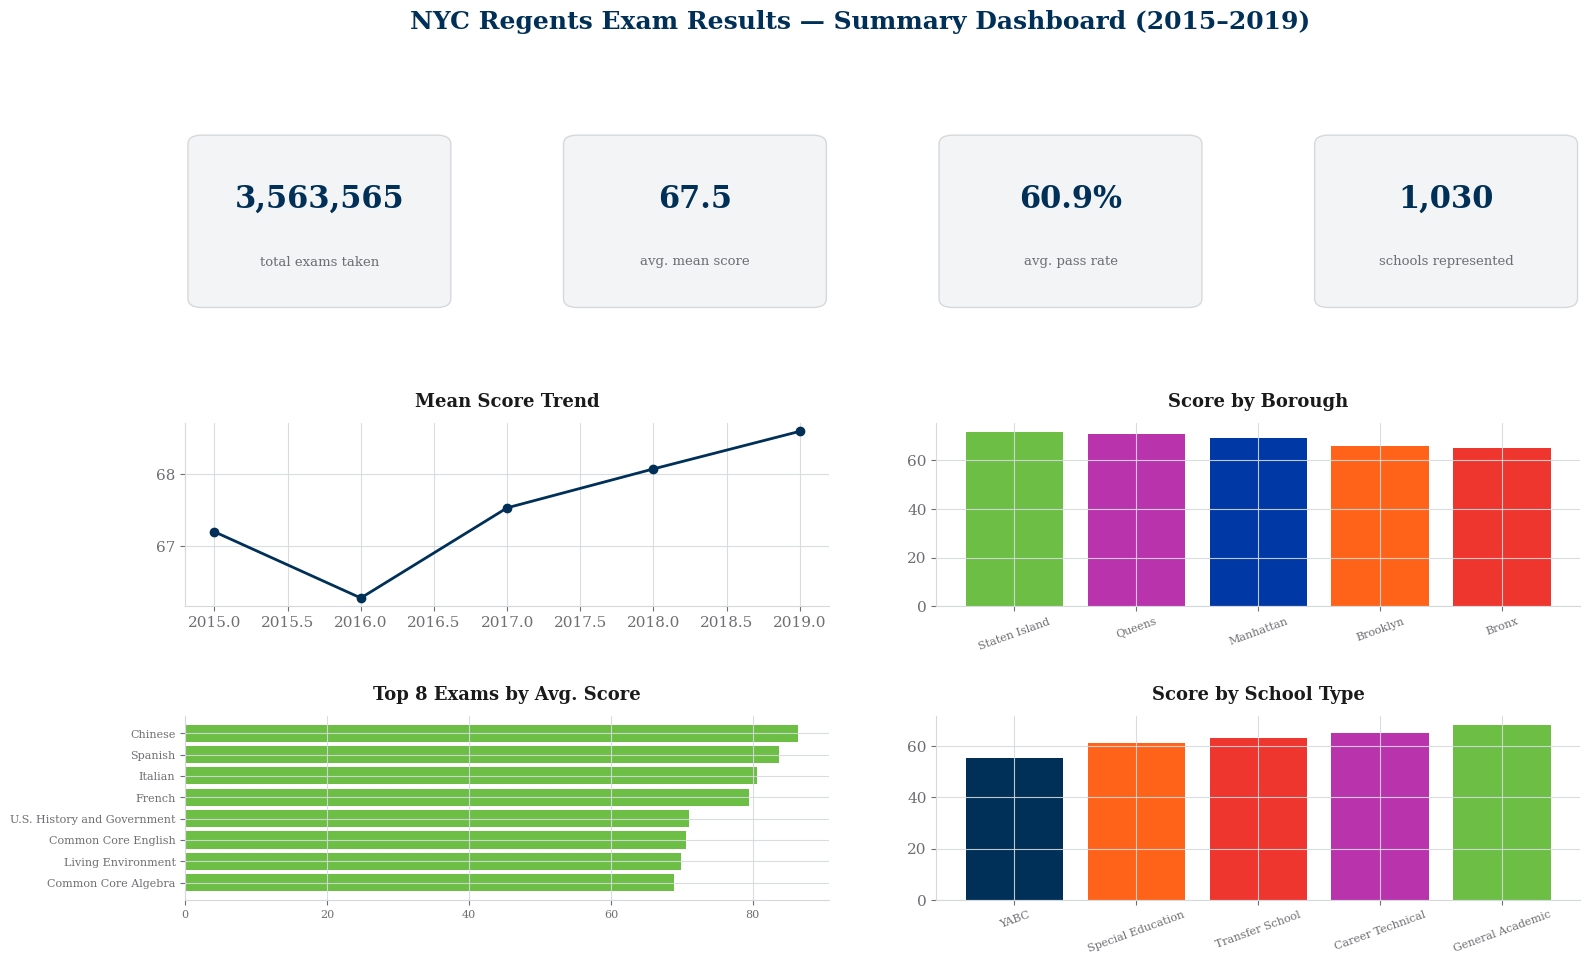

In [12]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.6, wspace=0.4)
fig.suptitle('NYC Regents Exam Results — Summary Dashboard (2015–2019)', fontsize=18, color=NAVY, fontweight='bold', y=1.0)

stat_cells = [
    (f"{df_clean['Total Tested'].sum():,.0f}", "total exams taken"),
    (f"{df_clean['Mean Score'].mean():.1f}", "avg. mean score"),
    (f"{df_clean['Percent Scoring 65 or Above'].mean():.1f}%", "avg. pass rate"),
    (f"{df_clean['School Name'].nunique():,}", "schools represented"),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.05",
                                 linewidth=1, edgecolor=GRID, facecolor=PANEL, transform=ax.transAxes))
    ax.text(0.5, 0.62, val, ha='center', va='center', fontsize=22, color=NAVY, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.28, lab, ha='center', va='center', fontsize=9.5, color=INK_SOFT, transform=ax.transAxes)

ax = fig.add_subplot(gs[1, :2])
ax.plot(year_trend.index, year_trend['mean_score'], color=NAVY, linewidth=2, marker='o')
style_ax(ax, 'Mean Score Trend', '', '')

ax = fig.add_subplot(gs[1, 2:])
bars = ax.bar(boro_stats.index, boro_stats['mean_score'], color=[BOROUGH_COLORS[b] for b in boro_stats.index])
style_ax(ax, 'Score by Borough', '', '')
plt.setp(ax.get_xticklabels(), rotation=20, fontsize=8)

ax = fig.add_subplot(gs[2, :2])
bars = ax.barh(exam_score_sorted.index[-8:], exam_score_sorted.values[-8:], color=SUBWAY_G)
style_ax(ax, 'Top 8 Exams by Avg. Score', '', '')
ax.tick_params(labelsize=8)

ax = fig.add_subplot(gs[2, 2:])
bars = ax.bar(type_score.index, type_score.values, color=PALETTE_CAT[:len(type_score)])
style_ax(ax, 'Score by School Type', '', '')
plt.setp(ax.get_xticklabels(), rotation=20, fontsize=8)

plt.show()


<h2 id="model" style="font-family:Arial,Helvetica,sans-serif; color:#003057; border-bottom:3px solid #003057; padding-bottom:8px;">🤖 11. Predicting the Mean Score</h2>
<p style="color:#4A4A4A; font-family:Arial,Helvetica,sans-serif;">We predict a school-exam-year's <code>Mean Score</code> from categorical and structural fields — a reasonable real-world task (e.g. flagging schools/exams likely to underperform for targeted support).</p>

In [13]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model_df = df_clean.copy()
cat_cols = ['School Type', 'School Level', 'Regents Exam', 'Borough']
for c in cat_cols:
    model_df[c] = LabelEncoder().fit_transform(model_df[c].astype(str))

features = ['School Type', 'School Level', 'Regents Exam', 'Borough', 'Year', 'Total Tested']
X = model_df[features]
y = model_df['Mean Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

models = {
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    results[name] = {'model': m, 'pred': pred, 'r2': r2, 'mae': mae}
    print(f"{name}: R² = {r2:.3f} | MAE = {mae:.2f} points")


Train: 23,600 rows | Test: 5,900 rows
Random Forest: R² = 0.489 | MAE = 6.42 points
XGBoost: R² = 0.528 | MAE = 6.16 points


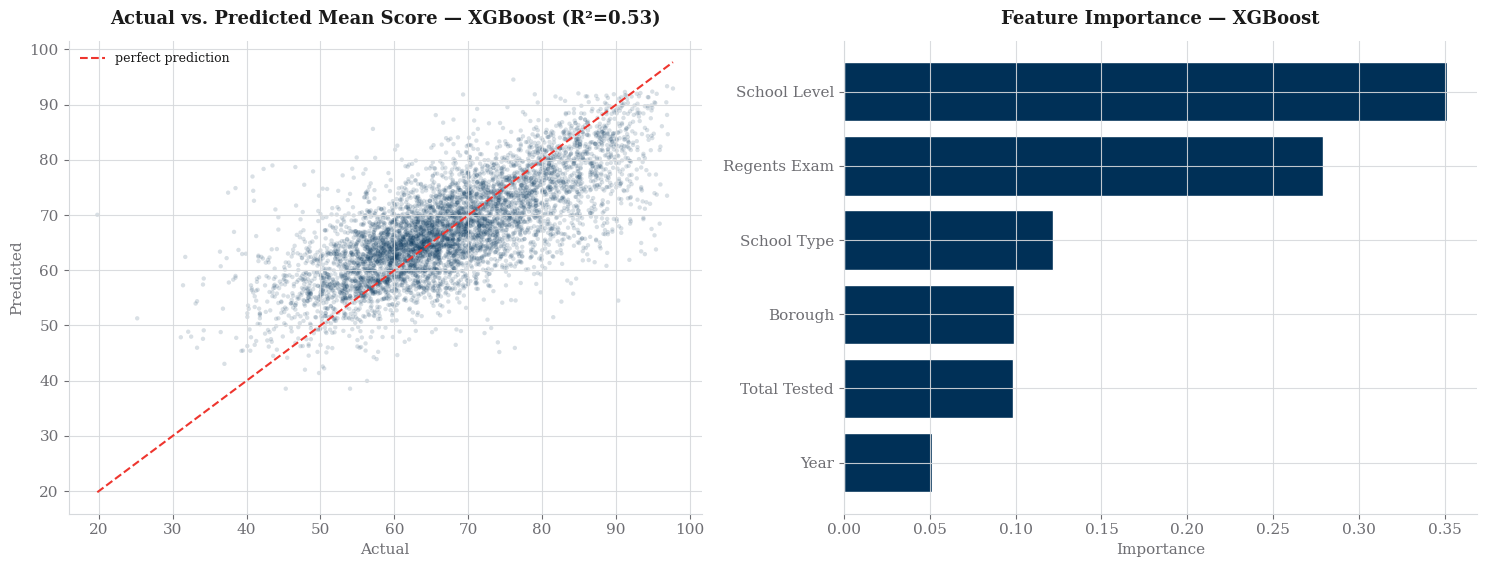

In [14]:

best_name = max(results, key=lambda k: results[k]['r2'])
best = results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
ax.scatter(y_test, best['pred'], alpha=0.15, s=10, color=NAVY, edgecolor='none')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, color=SUBWAY_4, linestyle='--', linewidth=1.5, label='perfect prediction')
style_ax(ax, f'Actual vs. Predicted Mean Score — {best_name} (R²={best["r2"]:.2f})', 'Actual', 'Predicted')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
importances = pd.Series(best['model'].feature_importances_, index=features).sort_values()
ax.barh(importances.index, importances.values, color=NAVY, edgecolor=BG)
style_ax(ax, f'Feature Importance — {best_name}', 'Importance', '')

plt.tight_layout()
plt.show()



<div style="background:#F2F4F6; border-left:3px solid #003057; padding:14px 20px; font-family:Arial,Helvetica,sans-serif; color:#333; font-size:14px;">
<b>Which exam a score belongs to dominates the prediction</b> — unsurprising given the wide score gap between,
say, Chinese/Spanish (heritage-language exams with strong average performance) and Algebra2/Trigonometry. School
type and level add real but smaller predictive value on top of that. This is a moderate-strength model (R² in the
0.4–0.6 range is typical here) rather than a near-perfect fit — appropriately so, since which specific school a
student attends and how that school serves its population matters more than what these five structural fields
alone can capture.
</div>



<div style="background:#F2F4F6; padding:36px 40px; border-radius:4px; border-top:6px solid #003057; font-family:Arial,Helvetica,sans-serif; color:#1A1A1A;">

<h2 id="conclusion" style="margin-top:0; font-weight:700; color:#003057; border-bottom:1px solid #D6D9DC; padding-bottom:10px;">📝 12. Closing Notes</h2>

<h4 style="color:#003057; font-weight:700; margin-bottom:6px;">What the data shows</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#333;">
<li>Citywide performance improved steadily from 2015 to 2019 — mean score up roughly 1.4 points and the 65+ pass rate up roughly 3.2 points over five years.</li>
<li>Heritage-language exams (Chinese, Spanish, Italian, French) post the highest average scores by a wide margin, while math exams (Algebra2/Trigonometry, Geometry) post the lowest — a pattern consistent with heritage/native speakers disproportionately taking those language Regents.</li>
<li>NYC's specialized and screened high schools (Stuyvesant, Bronx Science, Townsend Harris, and similar) occupy essentially the entire top-10 school ranking, matching well-documented real-world patterns for these exam-admission schools.</li>
<li>School type tells a coherent story: General Academic schools score highest, while YABC and Transfer Schools — programs explicitly designed for over-age, under-credit, or previously struggling students — score lowest, exactly as their mission would predict.</li>
</ul>

<h4 style="color:#003057; font-weight:700; margin-bottom:6px;">Handled carefully</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#333;">
<li>About 10.7% of rows are privacy-suppressed ('s') because their cohort is 5 students or fewer — these were excluded from aggregate analysis rather than imputed, since DOE withheld them by design.</li>
<li>"Total Tested" arrived as comma-formatted text for larger cohorts and needed explicit cleaning before use.</li>
</ul>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:Georgia,serif; font-size:12px; color:#6E6E73;">
— Muhammad Aamir
</p>

</div>
